# Redes neuronales

Estructura de una red de regresion:
Capa entrada
capas ocultas varias capas con activacion ReLu
Capas salidas una sola neurona sin activacion o con una lineal
Funcion de perdida: MSE
MEtricas de evaluacion MAE, R2

Clasificacion:
clasificacion binaria: neurona con activacion sigmoid
clasificacion multiclase: n neuronas con activacion softmax
funcion de perdida: mas usada:categorical_crossentropy o binary_crossentropy

Funciones de activacion permiten introducir no linealidad
comunes:
Relu     ->capas ocultas
Sigmoid  ->clasificacion binaria
Softmax  ->clasificacion multiple
tanh     ->menos usada, remplazada por relu

la eleccion depended de la tarea y la capa,


Optimizadores: se encargan de ajustar los pesos de la red
SGD: Descenso de gradiente estocastico
Adam:Adaptativo, recomendado en la mayoria de los casos

In [1]:
import pandas as pd 

In [19]:
df = pd.read_csv('Ecommerce.csv', sep=',')
df

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092
...,...,...,...,...,...,...,...,...
495,lewisjessica@craig-evans.com,"4483 Jones Motorway Suite 872\nLake Jamiefurt,...",Tan,33.237660,13.566160,36.417985,3.746573,573.847438
496,katrina56@gmail.com,"172 Owen Divide Suite 497\nWest Richard, CA 19320",PaleVioletRed,34.702529,11.695736,37.190268,3.576526,529.049004
497,dale88@hotmail.com,"0787 Andrews Ranch Apt. 633\nSouth Chadburgh, ...",Cornsilk,32.646777,11.499409,38.332576,4.958264,551.620145
498,cwilson@hotmail.com,"680 Jennifer Lodge Apt. 808\nBrendachester, TX...",Teal,33.322501,12.391423,36.840086,2.336485,456.469510


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    object 
 1   Address               500 non-null    object 
 2   Avatar                500 non-null    object 
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), object(3)
memory usage: 31.4+ KB


In [21]:
df.isnull().sum()

Email                   0
Address                 0
Avatar                  0
Avg. Session Length     0
Time on App             0
Time on Website         0
Length of Membership    0
Yearly Amount Spent     0
dtype: int64

In [22]:
X = df[['Avg. Session Length','Time on App','Time on Website','Length of Membership']]
y = df['Yearly Amount Spent']

In [23]:
#escalamiento de los datos
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_enc = scaler.fit_transform(X)
X_enc[:2]

array([[ 1.45635117,  0.60728003,  2.49358859,  0.55010651],
       [-1.13650215, -0.94946372,  0.20655573, -0.87092735]])

In [24]:
#separar los datos
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_enc, y, test_size=0.2, random_state=42)

### Arquitectura de la red neuronal

La arquitectura es un arte. En este caso, utilizaremos capas densas (fully connected)

*  Probar con activation: relu, tanh, linear
*  Probar optimizadores: Adam, SGD, RMSProp, Adagrad
*  Probar combinaciones de capas

In [25]:
from tensorflow import *
from keras import *

In [ ]:
from tensorflow.keras import Sequential #aqui se enncuentra la capa fullu connected
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.utils import plot_model

In [27]:
#Lineal
model = Sequential()  # definimos la estructura del  modelo
model.add(Input(shape=(4,))) #capa de entrada depende de las variables que tengamos en X
model.add(Dense(20, activation='linear')) #capa oculta hay que ir probando, de muy pocas e irlas aumentando
model.add(Dense(10, activation='linear')) #capa oculta
model.add(Dense(1, activation='linear')) #capa de salida depende tambien de cuantas salidas queremos. en este caso queremos una respuesta unica no algo multiclase

In [47]:
from tensorflow.keras.metrics import R2Score

In [48]:
model.compile(loss='mse',
              optimizer=Adam(learning_rate=0.01),
              metrics=[R2Score()])

In [49]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 20)             │           100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 321 (1.25 KB)

 Trainable params: 321 (1.25 KB)

 Non-trainable params: 0 (0.00 B)

In [50]:
X_train

array([[ 0.73314361, -0.13577217, -0.21368631,  0.10170962],
       [ 1.2354693 , -0.23133443, -0.74484059, -1.4185221 ],
       [-0.43903853,  1.95032608,  0.12883727,  0.53200325],
       ...,
       [-1.25125901, -1.17352219, -2.14231308, -0.40552112],
       [-0.79996391,  2.09460507, -0.03661911,  0.22900329],
       [-0.63283097, -0.6077061 ,  0.51486516, -0.94812651]],
      shape=(400, 4))

## entrenamiento

In [51]:
history = model.fit(X_train, y_train, batch_size=128, epochs=50, validation_split=0.1)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 151ms/step - loss: 166.2417 - r2_score: 0.9754 - val_loss: 126.8861 - val_r2_score: 0.9741
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 139.9276 - r2_score: 0.9793 - val_loss: 134.5057 - val_r2_score: 0.9726
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 110.0255 - r2_score: 0.9837 - val_loss: 126.2387 - val_r2_score: 0.9742
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 119.1866 - r2_score: 0.9824 - val_loss: 111.6991 - val_r2_score: 0.9772
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 112.9125 - r2_score: 0.9833 - val_loss: 145.1704 - val_r2_score: 0.9704
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 108.4891 - r2_score: 0.9839 - val_loss: 111.9475 - val_r2_score: 0.9772
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 105.9275 - r2_score: 0.9843 - val_loss: 116.5133 - val_r2_score: 0.9762
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 102.8857 - r2_score: 0.9848 - val_loss:

## Evaluación

In [34]:
from sklearn.metrics import r2_score

In [35]:
y_pred_train = model.predict(X_train)

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


In [36]:
r2_score(y_train,y_pred_train)

0.983962697009728

In [37]:
X_test[:5]

array([[-0.98389768, -1.7162456 ,  1.96607598, -0.09907246],
       [-0.24657454,  0.76984401, -0.02863481,  0.31866608],
       [-1.61939847, -1.96417105,  0.97377785,  0.70605065],
       [-0.60880414,  1.41482827,  0.17668564, -0.59307224],
       [-1.6777514 , -1.06548707,  1.00448656, -0.10478212]])

In [38]:
y_pred_test = model.predict(X_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


In [39]:
r2_score(y_test,y_pred_test)

0.9763511158995327

Para interpretar este ejemplo
R² train: 0.98
R² test:  0.976   ✅ excelente

otro caso
R² train: 0.99
R² test:  0.85   ⚠️ overfitting

## Evolución del entrenamiento

In [40]:
import matplotlib.pyplot as plt
%matplotlib inline

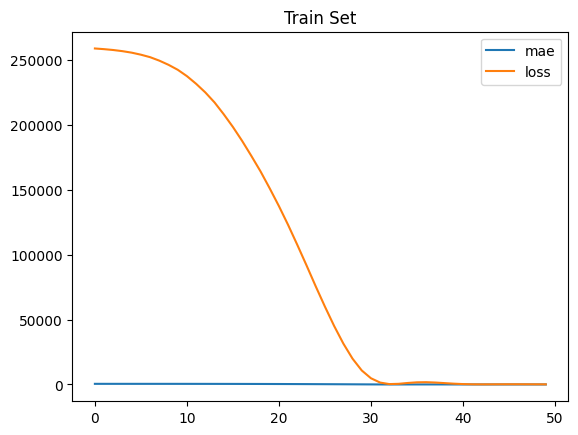

In [41]:
plt.title('Train Set')
plt.plot(history.history['mae'], label='mae')
plt.plot(history.history['loss'], label='loss')
plt.legend(loc=0)

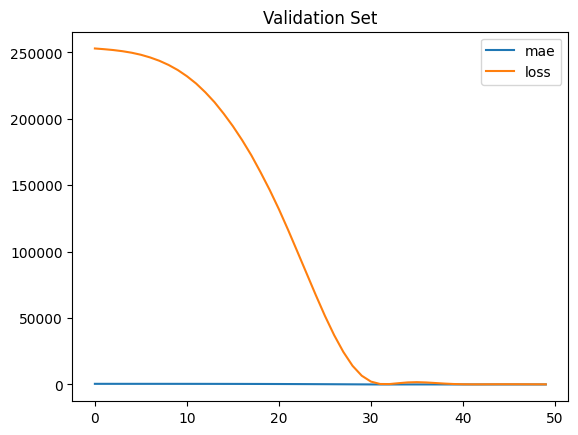

In [42]:
plt.title('Validation Set')
plt.plot(history.history['val_mae'], label='mae')
plt.plot(history.history['val_loss'], label='loss')
plt.legend(loc=0)